### Regression plots
1. Calculate NDJ Nino3.4 index using HadISST from 1948-2017
2. Calculate monthly temperature anomalies using NCEP/NCAR Reanalysis from 1948-12 to 2017-11 and smooth using 3-month running mean 
3. Calulate instantaneous regression between NDJ Nino3.4 index amd NDJ temperature anomalies 
4. Calculate regression between NDJ nino3.4 index and temperature anomalies 6 month either side
5. Repeat for precipitaion using NCEP/NCAR
6. Repeat for TXx and Rx1day

### Imports

In [1]:
import xarray as xr
import numpy as np
import sys
sys.path.append('/home/563/rl5183/PhD-research/Functions')
import functions as func
import matplotlib.pyplot as plt
import scipy.stats

### Data

In [2]:
#HadISST 1948-2017
hadisst_ds = xr.open_dataset('/g/data/eg3/jxb548/OBSDATA/hadisstv1.1870_2017.nc')
sst_data = hadisst_ds.sst.sel(time=slice('1948-12','2016-11'))
#NCEP/NCAR reanalysis
temp_ds = xr.open_dataset('/g/data/w40/rl5183/NCEP_NCAR_reanalysis/air.mon.mean.nc')
temp_data = temp_ds.air.sel(time=slice('1948-12', '2016-11'))

### Detrend

In [3]:
#detrend HadISST data
sst_data_detrend = np.apply_along_axis(func.detrend_2step, 0, sst_data)
sst_detrended = xr.DataArray(sst_data_detrend, coords=sst_data.coords, attrs=sst_data.attrs)
#detrend air temp data
temp_data_detrend = np.apply_along_axis(func.detrend_2step, 0, temp_data)
temp_detrended = xr.DataArray(temp_data_detrend, coords=temp_data.coords, attrs=temp_data.attrs)

### Calculate Nino3.4 index 

In [5]:
nino34_region = sst_detrended.sel(latitude=slice(5,-5), longitude=slice(-170,-120))
climatology = nino34_region.sel(time=slice('1950-01','1979-12')).groupby('time.month').mean()
monthly_anomalies = (nino34_region.groupby('time.month')-climatology).mean(dim=['latitude','longitude'])
monthly_anomalies_rolling = monthly_anomalies.rolling(time=5).mean()
sst_std = nino34_region.sel(time=slice('1950-01','1979-12')).std()
nino34_index = monthly_anomalies_rolling/sst_std

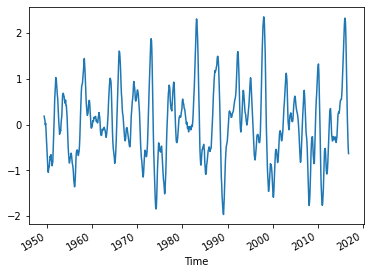

In [6]:
nino34_index.plot()

In [7]:
# Give nino index same grid as temp
nino34 = nino34_index.expand_dims(lat=temp_data.lat.values, lon = temp_data.lon.values)
nino34 = nino34.transpose('time', 'lat', 'lon')

### Calculate monthly temperature anomalies

In [8]:
climatology = temp_detrended.sel(time=slice('1950','1979')).groupby('time.month').mean()
temp_anom = temp_detrended.groupby('time.month')-climatology 

### Calculate instantaneous regression

In [16]:
def regress_nino(data, nino):
    """
    Returns the linear regression at each gridpoint of 'data' against 'nino'
    """
    
    # Function to apply on each gridpoint
    def regress_gridpoint(data):
        return scipy.stats.linregress(data, nino)[0]
    
    # Apply the function on each gridpoint
    regression = np.apply_along_axis(regress_gridpoint, data.get_axis_num('time'), data)
    
    # This is just to get the correct coordinates for the output
    sample = data.mean('time')
    
    # Convert the numpy array back into xarray
    return xr.DataArray(regression, sample.coords)

def regress_nino_by_season(data, nino):
    """
    Runs 'regress_nino' on each season separately
    """
    
    return data.groupby('time.season').map(regress_nino, nino=nino)


In [17]:
# The mean over every quarter, starting at Dec (seasonal mean)
seasonal_temp_anom = temp_anom.resample(time='QS-DEC').mean('time')
seasonal_nino = nino34.resample(time='QS-DEC').mean('time')

In [18]:
# The regression for each season between temp_anom and nino
seasonal_regression = regress_nino_by_season(seasonal_temp_anom, seasonal_nino)

ValueError: y has more than 2 dimensions